# Sentiment Analysis Duolingo Application

# Import Library

In [ ]:
!pip install emoji
!pip install python-Levenshtein
!pip install wordcloud
!pip install --upgrade git+https://github.com/ariaghora/mpstemmer.git

  Cloning https://github.com/ariaghora/mpstemmer.git to /tmp/pip-req-build-sns5l5ik
  Running command git clone --filter=blob:none --quiet https://github.com/ariaghora/mpstemmer.git /tmp/pip-req-build-sns5l5ik
  Resolved https://github.com/ariaghora/mpstemmer.git to commit 25a5fd923af163a7eac3a5ec976984156ca8fa8b
  Preparing metadata (setup.py) ... done
  Created wheel for mpstemmer: filename=mpstemmer-0.1.0-py3-none-any.whl size=99799 sha256=1da0071998e920bc593935b645f55e64ab7aa07a7be72b7d723496cf29dbf694
  Stored in directory: /tmp/pip-ephem-wheel-cache-h6j_ue7p/wheels/85/1f/78/fccc1e7e90613593e0a66304a3711d678e3013034d91534182
Successfully built mpstemmer


In [ ]:
import csv
import pandas as pd
import numpy as np
import os
import re
import emoji
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud
from io import StringIO
from mpstemmer import MPStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Library Deep Learning (Keras/TensorFlow)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, SimpleRNN, Embedding, SpatialDropout1D
from tensorflow.keras import Input
from tensorflow.keras.callbacks import Callback

# Preprocessing Data

## Data Cleaning

In [ ]:
# Menghapus kolom yang tidak diperlukan
df = df.drop(['reviewId', 'userName', 'userImage', 'thumbsUpCount', 'reviewCreatedVersion', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion'], axis = 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  45000 non-null  object
 1   score    45000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 703.3+ KB


In [ ]:
# Menghapus data kosong dan duplikat
df = df.dropna()
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44391 entries, 0 to 44999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  44391 non-null  object
 1   score    44391 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.0+ MB


In [ ]:
df.isnull().sum()

,0
content,0
score,0


In [ ]:
df.nunique()

,0
content,44311
score,5


## Text Pre-Processing

In [ ]:
def clean_text(text):

    # Replace semua karakter selain huruf/spasi dengan spasi
    text = re.sub(r'[^\w\s]', ' ', text)

    # Hapus semua angka
    text = re.sub(r'\d+', ' ', text)

    # Ganti emoji dengan spasi
    text = emoji.replace_emoji(text, replace=' ')

    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
# Mengubah teks menjadi huruf kecil
def lowercase_text(text):
    return text.lower()

In [ ]:
# Mengganti kata slang/gaul dengan kata baku
def replace_slang_words(text):
    slangwords = {
        '@': 'di', 'apk': 'aplikasi', 'abis': 'habis', 'bnr': 'benar', 'bgt': 'banget', 'btw': 'ngomong-ngomong',
        'cmiiw': 'jika saya tidak salah', 'dong': 'tolong', 'dpt': 'dapat', 'ga': 'tidak', 'gak': 'tidak',
        'gini': 'begini', 'gitu': 'begitu', 'gua': 'saya', 'gue': 'saya', 'hny': 'hanya', 'hrs': 'harus',
        'kalo': 'kalau', 'kan': 'bukan', 'kayak': 'seperti', 'krn': 'karena', 'loh': 'loh',
        'mlm': 'malam', 'nih': 'ini', 'pd': 'pada', 'pke': 'pakai', 'sbm': 'sebelum', 'sdh': 'sudah',
        'sih': 'sih', 'sy': 'saya', 'tdk': 'tidak', 'tuh': 'itu', 'udh': 'sudah', 'wkwk': 'tertawa',
        'wkwkwk': 'tertawa', 'wtb': 'ingin membeli', 'wts': 'ingin menjual', 'wtt': 'ingin menukar',
        'males': 'malas', 'yg': 'yang'
    }

    words = text.split()

    return ' '.join([slangwords.get(word.lower(), word) for word in words])

In [ ]:
# Melakukan tokenisasi teks menjadi daftar kata
def tokenize_text(text):
    text = word_tokenize(text)
    return text

In [ ]:
# Menghapus stopwords Bahasa Indonesia (default + tambahan custom)
def remove_stopwords(text):
    # Ambil stopwords Bahasa Indonesia dan tambahkan stopwords tambahan
    stopword_lists = set(stopwords.words('indonesian'))
    additional_stopwords = {
        'loh', 'banget', 'nah', 'gituan', 'oke', 'dong', 'ya', 'mereka', 'aja', 'kok',
        'nanti', 'ku', 'yang', 'gak', 'mesti', 'iya', 'lagi', 'kayaknya', 'woy', 'ok',
        'lah', 'seperti', 'dah', 'tau', 'pas', 'bangettt', 'yuk', 'biar', 'gue', 'tidak',
        'abis', 'bikin', 'loh', 'enggak', 'gitu', 'ada', 'nih', 'mah', 'na', 'nya',
        'ko', 'agak', 'kalo', 'tuh', 'udah', 'yaa', 'atau', 'pasti', 'wow', 'gua',
        'kayak', 'benar', 'adalah', 'mau', 'dikit', 'lagi', 'sih', 'anjay', 'lho', 'juga'
    }
    stopword_lists.update(additional_stopwords)

    # Hapus stopwords dari daftar token
    filtered_text = [word for word in text if word.lower() not in stopword_lists]

    return filtered_text

In [ ]:
# Melakukan stemming/lemmatization pada setiap token
def lemmatize_text(text):
    stemmer = MPStemmer()
    stemmed_text = [stemmer.stem(token) for token in text]
    return stemmed_text

In [ ]:
# Menggabungkan kembali token menjadi satu string
def join_tokens(tokens):
    # Combine the list of tokens into one string, with spaces as the separator
    return ' '.join(tokens)

In [ ]:
# Bersihkan teks dan simpan di kolom 'clean_text'
df['clean_text'] = df['content'].apply(clean_text)

# Ubah teks menjadi huruf kecil semua dan simpan di kolom 'lowercase_text'
df['lowercase_text'] = df['clean_text'].apply(lowercase_text)

# Ganti kata slang menjadi kata baku dan simpan di kolom 'slang_replaced_text'
df['slang_replaced_text'] = df['lowercase_text'].apply(replace_slang_words)

# Tokenisasi teks menjadi daftar kata dan simpan di kolom 'tokenized_text'
df['tokenized_text'] = df['slang_replaced_text'].apply(tokenize_text)

# Hapus stopwords dari token dan simpan di kolom 'no_stopwords_text'
df['no_stopwords_text'] = df['tokenized_text'].apply(remove_stopwords)

# Lakukan stemming/lemmatization dan simpan di kolom 'lemmatized_text'
df['lemmatized_text'] = df['no_stopwords_text'].apply(lemmatize_text)

# Gabungkan token kembali menjadi kalimat dan simpan di kolom 'final_clean_text'
df['final_clean_text'] = df['lemmatized_text'].apply(join_tokens)

In [ ]:
df.head()

,content,score,clean_text,lowercase_text,slang_replaced_text,tokenized_text,no_stopwords_text,lemmatized_text,final_clean_text
0,apknya sudah keren cuma caturnya kurang dari s...,5,apknya sudah keren cuma caturnya kurang dari s...,apknya sudah keren cuma caturnya kurang dari s...,apknya sudah keren cuma caturnya kurang dari s...,"[apknya, sudah, keren, cuma, caturnya, kurang,...","[apknya, keren, caturnya, segi, warna, susah, ...","[apknya, keren, catur, segi, warna, susah, tin...",apknya keren catur segi warna susah tingkat ak...
1,"jujur, aplikasi ini nge bantu aku untuk belaja...",4,jujur aplikasi ini nge bantu aku untuk belajar...,jujur aplikasi ini nge bantu aku untuk belajar...,jujur aplikasi ini nge bantu aku untuk belajar...,"[jujur, aplikasi, ini, nge, bantu, aku, untuk,...","[jujur, aplikasi, nge, bantu, belajar, bahasa,...","[jujur, aplikasi, nge, bantu, ajar, bahasa, se...",jujur aplikasi nge bantu ajar bahasa sel seles...
2,sebenarnya untuk aplikasi ini bagus mengajar d...,4,sebenarnya untuk aplikasi ini bagus mengajar d...,sebenarnya untuk aplikasi ini bagus mengajar d...,sebenarnya untuk aplikasi ini bagus mengajar d...,"[sebenarnya, untuk, aplikasi, ini, bagus, meng...","[aplikasi, bagus, mengajar, mengasah, berkemba...","[aplikasi, bagus, ajar, asah, kembang, update,...",aplikasi bagus ajar asah kembang update suka g...
3,bisa memelajari apa yg kita tidak tahu tpi ini...,5,bisa memelajari apa yg kita tidak tahu tpi ini...,bisa memelajari apa yg kita tidak tahu tpi ini...,bisa memelajari apa yang kita tidak tahu tpi i...,"[bisa, memelajari, apa, yang, kita, tidak, tah...","[memelajari, tpi, sungguh, seru, melatih, otak...","[memelajari, tpi, sungguh, seru, latih, otak, ...",memelajari tpi sungguh seru latih otak cerdas ...
4,"Untuk romaji nya dikoreksi kembali, untuk cont...",5,Untuk romaji nya dikoreksi kembali untuk conto...,untuk romaji nya dikoreksi kembali untuk conto...,untuk romaji nya dikoreksi kembali untuk conto...,"[untuk, romaji, nya, dikoreksi, kembali, untuk...","[romaji, dikoreksi, contoh, kebanyakan, belaja...","[romaji, koreksi, contoh, kebanyakan, ajar, ot...",romaji koreksi contoh kebanyakan ajar otodidak...


In [ ]:
df.to_csv('processed_review.csv', index=False)

# Data Load Preprocesed

In [ ]:
import pandas as pd
df = pd.read_csv('processed_review.csv')

In [ ]:
df = df.dropna()

In [ ]:
# Mengonversi string ke list menggunakan literal_eval
import ast
def string_to_list(s):
    return ast.literal_eval(s)

In [ ]:
# Menerapkan fungsi parsing untuk mengubah string kembali menjadi list pada kolom tertentu
df['tokenized_text'] = df['tokenized_text'].apply(string_to_list)
df['no_stopwords_text'] = df['no_stopwords_text'].apply(string_to_list)
df['lemmatized_text'] = df['lemmatized_text'].apply(string_to_list)

# Data Labeling

In [72]:
# Mengambil data lexicon sentimen (positif & negatif) dari URL dan menyimpannya dalam bentuk dictionary
import requests

def fetch_lexicon(url):
    lexicon = dict()
    response = requests.get(url)

    if response.status_code == 200:
        # Membaca file TSV (tab-separated) dan mengabaikan header
        reader = csv.reader(StringIO(response.text), delimiter='\t')
        next(reader)
        for row in reader:
            lexicon[row[0]] = int(row[1])
    else:
        print(f"Gagal mengambil data lexicon dari {url}")

    return lexicon

# URL lexicon positif dan negatif dari dataset InSet
url_positive = 'https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv'
url_negative = 'https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv'

# Mengambil dan menyimpan lexicon positif dan negatif
lexicon_positive = fetch_lexicon(url_positive)
lexicon_negative = fetch_lexicon(url_negative)

In [73]:
# Fungsi untuk menghitung skor sentimen berdasarkan lexicon Indonesia dan menentukan polaritasnya
def analyze_sentiment_indonesian(text):
    # Hitung skor dengan menjumlahkan nilai dari lexicon positif dan negatif
    score = sum(lexicon_positive.get(word, 0) + lexicon_negative.get(word, 0) for word in text)

    # Menentukan label sentimen berdasarkan skor
    if score > 0:
        return score, 'positive'   # Skor > 0 → positif
    elif score < 0:
        return score, 'negative'   # Skor < 0 → negatif
    else:
        return score, 'neutral'    # Skor = 0 → netral


# Menerapkan analisis sentimen ke setiap baris pada kolom 'lemmatized_text'
sentiment_results = df['lemmatized_text'].apply(analyze_sentiment_indonesian)

# Memisahkan hasil menjadi dua kolom: skor dan label polaritas
df[['polarity_score', 'polarity']] = pd.DataFrame(sentiment_results.tolist(), index=df.index)

# Menampilkan distribusi jumlah tiap label sentimen
df['polarity'].value_counts()

,count
polarity,
negative,13765
positive,2657
neutral,825


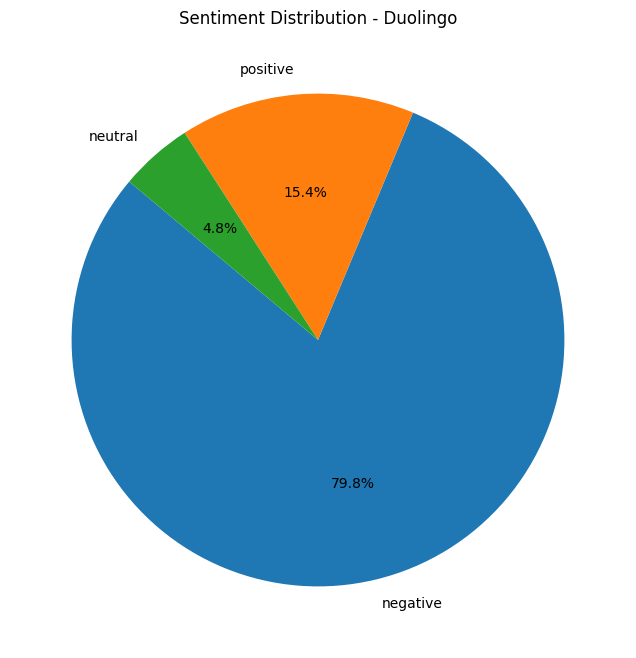

In [74]:
# Mengambil jumlah masing-masing label sentimen dari kolom polarity
polarity_counts = df['polarity'].value_counts()

# Membuat visualisasi pie chart untuk menampilkan distribusi sentimen
plt.figure(figsize=(8, 8))
plt.pie(polarity_counts, labels=polarity_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Sentiment Distribution - Duolingo')
plt.show()

In [75]:
# Fungsi untuk membuat visualisasi word cloud dari teks berdasarkan kategori sentimen
def generate_wordcloud(text, title):
    # Membuat objek wordcloud dari teks yang diberikan
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    # Menampilkan hasil wordcloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

In [76]:
# Memastikan semua data pada kolom 'final_clean_text' bertipe string
df['final_clean_text'] = df['final_clean_text'].astype(str)

# Menggabungkan seluruh teks untuk masing-masing kategori sentimen
general_text = ' '.join(df['final_clean_text'])
positive_text = ' '.join(df[df['polarity'] == 'positive']['final_clean_text'])
negative_text = ' '.join(df[df['polarity'] == 'negative']['final_clean_text'])
neutral_text = ' '.join(df[df['polarity'] == 'neutral']['final_clean_text'])

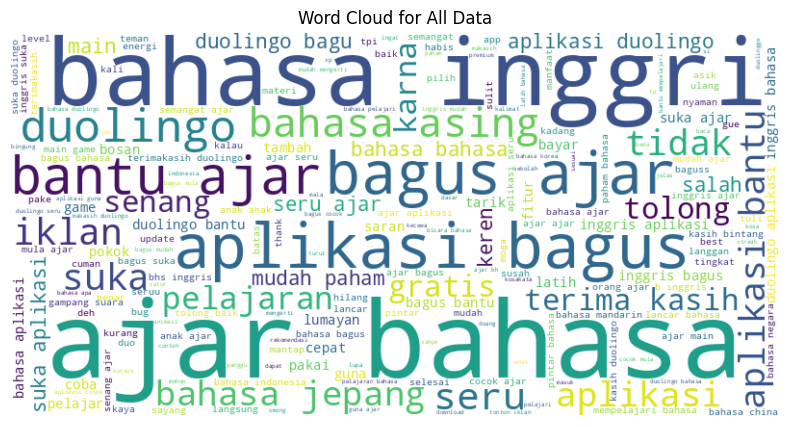

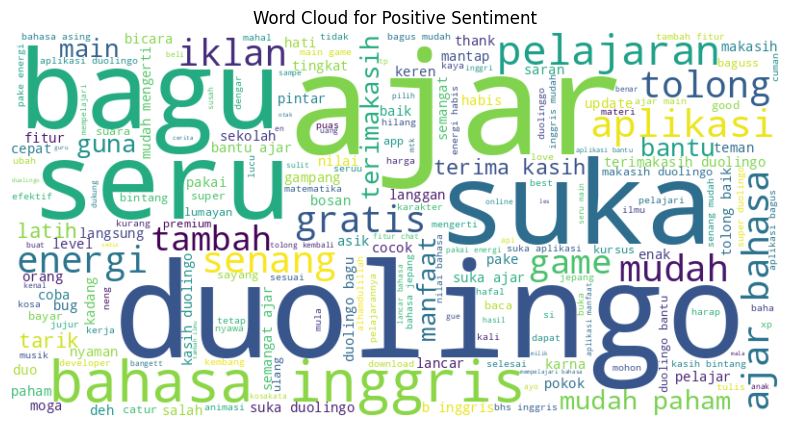

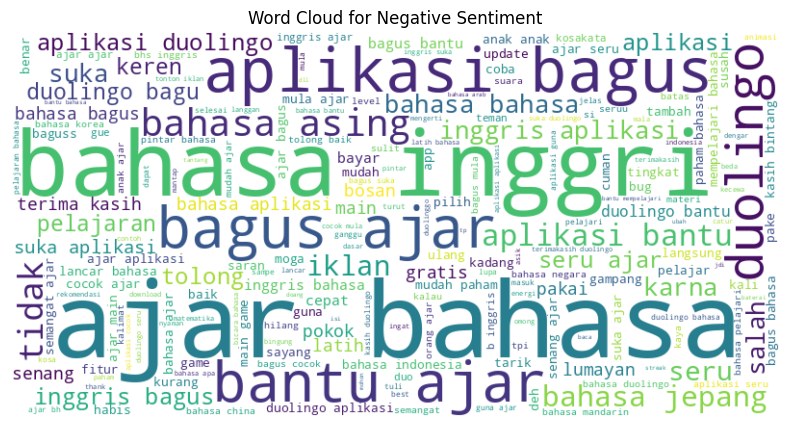

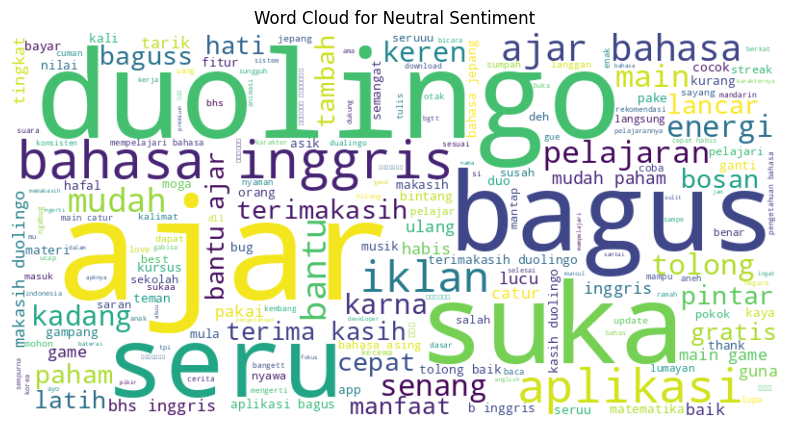

In [77]:
# Membuat word cloud untuk seluruh data dan masing-masing kategori sentimen
generate_wordcloud(general_text, "Word Cloud for All Data")
generate_wordcloud(positive_text, "Word Cloud for Positive Sentiment")
generate_wordcloud(negative_text, "Word Cloud for Negative Sentiment")
generate_wordcloud(neutral_text, "Word Cloud for Neutral Sentiment")

# Feature Extraction and Modeling

In [78]:
# Membuat DataFrame kosong untuk menyimpan hasil evaluasi setiap model
results_df = pd.DataFrame(columns=['Model', 'Validation Accuracy', 'Test Accuracy'])

## Kombinasi 1: MLP + TF-IDF

In [79]:
# Menentukan fitur (teks) dan label (sentimen) untuk pemodelan
X = df['final_clean_text']
y = df['polarity']

In [80]:
# Menginisialisasi TF-IDF Vectorizer untuk mengubah teks menjadi fitur numerik
tfidf_vectorizer = TfidfVectorizer(max_features=10000)

# Melakukan fit dan transformasi seluruh data teks menjadi representasi TF-IDF
X_tfidf = tfidf_vectorizer.fit_transform(X).toarray()

In [81]:
# Membagi data menjadi data latih (70%), validasi (15%), dan uji (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_tfidf,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Membagi sisa data menjadi validasi dan uji dengan proporsi sama
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [82]:
# Menginisialisasi model MLP Classifier untuk klasifikasi sentimen
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)

# Melatih model menggunakan data latih
mlp_model.fit(X_train, y_train)

MLPClassifier(max_iter=300, random_state=42)

In [83]:
# Melakukan prediksi pada data uji dan menghitung akurasi
y_test_pred = mlp_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Melakukan inferensi pada data uji untuk mendapatkan label kategori
y_test_pred_categorical = mlp_model.predict(X_test)

# Membuat DataFrame untuk membandingkan label asli dan prediksi
output_df_model_1 = pd.DataFrame({
    'True Label': y_test,
    'Predicted Label': y_test_pred_categorical
})

# Menampilkan beberapa baris awal hasil perbandingan
output_df_model_1.head()

,True Label,Predicted Label
12299,negative,negative
10020,negative,negative
11583,negative,negative
15276,negative,negative
2254,negative,negative


In [84]:
# Melakukan prediksi pada data validasi dan menghitung akurasi validasi
y_val_pred = mlp_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

# Melakukan prediksi pada data uji dan menghitung akurasi uji
y_test_pred = mlp_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Menyimpan hasil evaluasi model ke dalam DataFrame hasil
results_df = pd.concat([results_df, pd.DataFrame({
    'Model': ['MLP + TF-IDF'],
    'Validation Accuracy': [f'{val_accuracy:.4f}'],
    'Test Accuracy': [f'{test_accuracy:.4f}']
})], ignore_index=True)

# Menampilkan DataFrame hasil evaluasi
results_df

,Model,Validation Accuracy,Test Accuracy
0,MLP + TF-IDF,0.9266,0.9301


## Kombinasi 2: LSTM + TF-IDF

In [85]:
X = df['final_clean_text']
y = df['polarity']

In [86]:
# Menginisialisasi TF-IDF Vectorizer dengan jumlah fitur lebih kecil
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Melakukan fit dan transformasi teks menjadi representasi TF-IDF
X_tfidf = tfidf_vectorizer.fit_transform(X).toarray()

# Mengubah bentuk data agar sesuai dengan input LSTM (samples, timesteps, features)
X_tfidf = np.expand_dims(X_tfidf, axis=1)

In [87]:
# Menginisialisasi LabelEncoder dan mengubah label sentimen menjadi numerik
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

In [88]:
# Membagi data numerik menjadi data latih (70%), validasi (15%), dan uji (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_tfidf,
    y_enc,
    test_size=0.3,
    random_state=42,
    stratify=y_enc
)

# Membagi sisa data menjadi validasi dan uji dengan proporsi sama
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [89]:
# Mendefinisikan callback kustom untuk menghentikan training saat akurasi validasi mencapai 92%
class StopTrainingAtAccuracy(Callback):
    def __init__(self, validation_threshold=92):
        super(StopTrainingAtAccuracy, self).__init__()
        self.validation_threshold = validation_threshold

    def on_epoch_end(self, epoch, logs=None):
        # Mengecek akurasi validasi pada setiap akhir epoch
        val_accuracy = logs.get('val_accuracy') * 100
        if val_accuracy >= self.validation_threshold:
            # Menghentikan training jika ambang batas tercapai
            print(f"\nValidation accuracy reached {val_accuracy:.2f}%, stopping training...")
            self.model.stop_training = True

In [90]:
# Membangun arsitektur model LSTM untuk klasifikasi sentimen
model = Sequential([
    # Layer input untuk menentukan bentuk data masukan
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    # Layer LSTM pertama untuk menangkap pola sekuensial
    LSTM(128, return_sequences=True),

    # Dropout untuk mengurangi overfitting
    Dropout(0.3),

    # Layer LSTM kedua untuk pemrosesan lanjutan
    LSTM(64),

    # Dropout tambahan untuk regularisasi
    Dropout(0.3),

    # Layer Dense untuk mempelajari pola kompleks
    Dense(32, activation='relu'),

    # Layer output dengan softmax untuk klasifikasi 3 kelas
    Dense(3, activation='softmax')
])

# Mengompilasi model dengan optimizer, fungsi loss, dan metrik akurasi
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [91]:
# Menginisialisasi callback kustom untuk kontrol penghentian training
stop_training_callback = StopTrainingAtAccuracy(validation_threshold=92)

# Melatih model menggunakan data latih dan memantau data validasi
history = model.fit(
    X_train,
    y_train,
    epochs=7,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[stop_training_callback]
)

Epoch 1/7
95/95 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.7728 - loss: 0.8986 - val_accuracy: 0.7982 - val_loss: 0.5085
Epoch 2/7
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.8012 - loss: 0.4590 - val_accuracy: 0.8894 - val_loss: 0.3317
Epoch 3/7
95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9184 - loss: 0.2364 - val_accuracy: 0.9119 - val_loss: 0.2414
Epoch 4/7
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9430 - loss: 0.1368 - val_accuracy: 0.9157 - val_loss: 0.2420
Epoch 5/7
94/95 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9535 - loss: 0.0967
Validation accuracy reached 92.08%, stopping training...
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9536 - loss: 0.0967 - val_accuracy: 0.9208 - val_loss: 0.2501


In [92]:
# Melakukan prediksi pada data uji menggunakan model LSTM
y_pred = model.predict(X_test)

# Mengubah hasil probabilitas menjadi label kelas
y_pred_classes = label_encoder.inverse_transform(np.argmax(y_pred, axis=1))

# Membuat DataFrame untuk membandingkan label asli dan hasil prediksi
output_df_model_2 = pd.DataFrame({
    'True Label': label_encoder.inverse_transform(y_test),
    'Predicted Label': y_pred_classes
})

# Menampilkan beberapa baris awal hasil prediksi
output_df_model_2.head()

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


,True Label,Predicted Label
0,negative,negative
1,negative,negative
2,negative,negative
3,negative,negative
4,negative,negative


In [93]:
# Mengevaluasi model pada data validasi dan data uji
val_loss, val_accuracy = model.evaluate(X_val, y_val)
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# Menampilkan nilai akurasi validasi dan uji
print(f'Validation Accuracy: {val_accuracy:.2f}')
print(f'Test Accuracy: {test_accuracy:.2f}')

# Menyimpan hasil evaluasi model ke dalam DataFrame hasil
results_df = pd.concat([results_df, pd.DataFrame({
    'Model': ['LSTM + TF-IDF'],
    'Validation Accuracy': [f'{val_accuracy:.4f}'],
    'Test Accuracy': [f'{test_accuracy:.4f}']
})], ignore_index=True)

# Menampilkan DataFrame hasil evaluasi terbaru
results_df

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9154 - loss: 0.2538
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9141 - loss: 0.2742
Validation Accuracy: 0.92
Test Accuracy: 0.91


,Model,Validation Accuracy,Test Accuracy
0,MLP + TF-IDF,0.9266,0.9301
1,LSTM + TF-IDF,0.9208,0.9138


## Kombinasi 3: RNN + Bag of Words

In [94]:
X = df['final_clean_text']
y = df['polarity']

In [95]:
# Menginisialisasi CountVectorizer untuk representasi Bag of Words
vectorizer = CountVectorizer(max_features=5000)  # Membatasi jumlah fitur kata paling sering

# Melakukan fit dan transformasi seluruh teks menjadi fitur BoW
X_bow = vectorizer.fit_transform(X).toarray()

In [96]:
# Menginisialisasi LabelEncoder dan mengubah label sentimen menjadi numerik
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

In [97]:
# Membagi data BoW menjadi data latih (70%), validasi (15%), dan uji (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_bow,
    y_enc,
    test_size=0.3,
    random_state=42,
    stratify=y_enc
)

# Membagi sisa data menjadi validasi dan uji dengan proporsi sama
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [98]:
# Mengubah bentuk data agar sesuai dengan kebutuhan input RNN
X_train_bow = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val_bow = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test_bow = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

In [99]:
# Membangun arsitektur model Simple RNN untuk klasifikasi sentimen
model = Sequential([
    # Layer input untuk menentukan bentuk data masukan
    Input(shape=(1, X_train_bow.shape[2])),

    # Layer Simple RNN pertama untuk menangkap dependensi sekuensial
    SimpleRNN(128, return_sequences=True),

    # Dropout untuk mengurangi overfitting
    Dropout(0.3),

    # Layer Simple RNN kedua untuk pemrosesan lanjutan
    SimpleRNN(64, return_sequences=False),

    # Layer Dense untuk ekstraksi fitur tambahan
    Dense(32, activation='relu'),

    # Dropout tambahan untuk regularisasi
    Dropout(0.3),

    # Layer output dengan softmax untuk klasifikasi 3 kelas
    Dense(3, activation='softmax')
])

# Mengompilasi model dengan optimizer, fungsi loss, dan metrik akurasi
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [100]:
# Melatih model Simple RNN menggunakan data latih dan memantau data validasi
history = model.fit(
    X_train_bow,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_bow, y_val)
)

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8229 - loss: 0.5250 - val_accuracy: 0.9146 - val_loss: 0.2592
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9297 - loss: 0.1981 - val_accuracy: 0.9281 - val_loss: 0.2419
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9567 - loss: 0.1242 - val_accuracy: 0.9304 - val_loss: 0.2408
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9653 - loss: 0.0965 - val_accuracy: 0.9296 - val_loss: 0.2512
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9726 - loss: 0.0746 - val_accuracy: 0.9269 - val_loss: 0.2826
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9791 - loss: 0.0596 - val_accuracy: 0.9320 - val_loss: 0.3015
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9816 - loss: 0.0513 - val_accuracy: 0.9308 - val_loss: 0.3208
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9828 - loss: 0.0453 - val_accu

In [101]:
# Membuat DataFrame untuk membandingkan label asli dan label hasil prediksi
output_df = pd.DataFrame({
    'True Label': label_encoder.inverse_transform(y_test),
    'Predicted Label': y_test_pred_categorical
})

# Menampilkan beberapa baris awal hasil perbandingan
output_df.head()

,True Label,Predicted Label
0,negative,negative
1,negative,negative
2,negative,negative
3,negative,negative
4,negative,negative


In [102]:
# Mengevaluasi model pada data validasi dan menampilkan akurasinya
val_loss, val_accuracy = model.evaluate(X_val_bow, y_val, verbose=0)
print(f'Validation Accuracy: {val_accuracy:.2f}')

# Mengevaluasi model pada data uji dan menampilkan akurasinya
test_loss, test_accuracy = model.evaluate(X_test_bow, y_test, verbose=0)
print(f'Test Accuracy: {test_accuracy:.2f}')

# Menyimpan hasil evaluasi model ke dalam DataFrame hasil
results_df = pd.concat([results_df, pd.DataFrame({
    'Model': ['Simple RNN + Bag of Words'],
    'Validation Accuracy': [f'{val_accuracy:.4f}'],
    'Test Accuracy': [f'{test_accuracy:.4f}']
})], ignore_index=True)

# Menampilkan DataFrame hasil evaluasi terbaru
results_df

Validation Accuracy: 0.93
Test Accuracy: 0.92


,Model,Validation Accuracy,Test Accuracy
0,MLP + TF-IDF,0.9266,0.9301
1,LSTM + TF-IDF,0.9208,0.9138
2,Simple RNN + Bag of Words,0.9285,0.9216


In [103]:
# Mengubah nilai akurasi menjadi format persentase
results_df['Validation Accuracy'] = results_df['Validation Accuracy'].astype(float) * 100
results_df['Test Accuracy'] = results_df['Test Accuracy'].astype(float) * 100

# Menambahkan kolom untuk mengecek apakah akurasi ≥ 85%
results_df['Validation > 85%'] = results_df['Validation Accuracy'] >= 85
results_df['Test > 85%'] = results_df['Test Accuracy'] >= 85

# Menampilkan DataFrame hasil akhir
results_df

,Model,Validation Accuracy,Test Accuracy,Validation > 85%,Test > 85%
0,MLP + TF-IDF,92.66,93.01,True,True
1,LSTM + TF-IDF,92.08,91.38,True,True
2,Simple RNN + Bag of Words,92.85,92.16,True,True


In [104]:
!pip freeze > requirements.txt